# Airline Delay Analytics with PySpark
### Portfolio data analytics project

This notebook performs an end-to-end analysis of airline arrival delays using PySpark. It demonstrates a scalable workflow for inspecting raw data, validating missing values, engineering delay-rate metrics, aggregating large datasets in Spark, and converting only small summary tables to pandas for visualisation.

## Business objective
Airlines, airports, and operations teams need to understand where delay risk is concentrated and how it changes over time. This analysis examines flight-delay trends, airline performance, airport performance, operational delay causes, and seasonal patterns.

## Questions answered
1. How have overall flight delays changed over time?
2. Which airlines have the highest percentage of delayed flights?
3. Which airlines experience the most carrier-caused delays?
4. Which airports have the highest delay rates?
5. What are the dominant causes of delays across all flights?
6. How do delay causes vary by season?
7. Which months have the highest and lowest delay percentages?

## Technical approach
`Raw CSV → Spark DataFrame inspection → missing-value validation → clean analytical dataset → weighted aggregations in Spark → small pandas tables → Matplotlib charts`

> **Publication note:** Before sharing this project publicly, add the official dataset source and licence information to the repository README or `data/README.md`.

---

## 1. Environment Setup
The notebook installs PySpark and starts a Spark session. A Spark session is the entry point to distributed DataFrame operations such as reading CSV files, applying transformations, grouping records, and computing aggregations.


In [1]:
%pip install pyspark

In [2]:
from pyspark.sql import SparkSession

from pyspark.sql import functions as F

spark =(
    SparkSession.builder
    .appName("Airline_Delay_Analytics")
    .master("local[*]")
    .getOrCreate()
)

## 1.1 Load the Raw Airline Dataset

The dataset is read into `airline_raw`, which is the unmodified source DataFrame. The `header=True` option uses the first CSV row as column names, while `inferSchema=True` allows Spark to infer numerical and text data types needed for calculations.

The preview and schema check should be reviewed before analysis starts, because calculations such as delay rates depend on `arr_flights` and `arr_del15` being recognised as numeric columns.


In [3]:
# Update this file path when running the notebook in a new Colab session or local environment.
file_path = "/content/sample_data/Airline_Delay_Cause (8).csv"

airline_raw = spark.read.csv(
    file_path,
    header=True,
    inferSchema=True
    )

airline_raw.show(10, truncate = False)
airline_raw.printSchema()

+----+-----+-------+-------------+-------+------------------------------------------------------------+-----------+---------+----------+----------+------+-----------+----------------+-------------+------------+---------+-------------+-------------+---------+--------------+-------------------+
|year|month|carrier|carrier_name |airport|airport_name                                                |arr_flights|arr_del15|carrier_ct|weather_ct|nas_ct|security_ct|late_aircraft_ct|arr_cancelled|arr_diverted|arr_delay|carrier_delay|weather_delay|nas_delay|security_delay|late_aircraft_delay|
+----+-----+-------+-------------+-------+------------------------------------------------------------+-----------+---------+----------+----------+------+-----------+----------------+-------------+------------+---------+-------------+-------------+---------+--------------+-------------------+
|2025|1    |G4     |Allegiant Air|ELM    |Elmira/Corning, NY: Elmira/Corning Regional                 |30         |0  

## 2. Initial Data Inspection and Coverage

Before transforming the CSV, this section checks the dataset size, Spark partition count, and the available year-month periods. These checks confirm that Spark loaded the file successfully and establish the time coverage of the analysis.

The raw dataset is intentionally left unchanged and stored as `airline_raw`. Keeping an untouched source DataFrame is a useful data-engineering practice because it gives us a reliable reference point if a cleaning or transformation decision later needs to be reviewed.

### Dataset Size and Spark Partitioning

This cell reports the number of rows, columns, and Spark partitions. `count()` is a Spark action: it causes Spark to scan the DataFrame and return a real row count. Partition count describes how Spark has split the data for parallel processing; it is inspected here rather than changed unnecessarily.


In [4]:
num_columns = len(airline_raw.columns)
num_rows = airline_raw.count()
num_partitions = airline_raw.rdd.getNumPartitions()

print(f"Number of columns: {num_columns}")
print(f"Number of rows: {num_rows}")
print(f"Number of partitions: {num_partitions}")


Number of columns: 21
Number of rows: 398233
Number of partitions: 2


### Available Time Periods

The analysis is time-based, so this step lists distinct `year` and `month` combinations in chronological order. It confirms the periods available for the trend and seasonality charts and helps prevent accidental assumptions about dataset coverage.


In [5]:
airline_raw.select(
    "year",
    "month"
).distinct().orderBy(
    F.col("year"),
    F.col("month")
).show(10, truncate = False)

+----+-----+
|year|month|
+----+-----+
|2003|6    |
|2003|7    |
|2003|8    |
|2003|9    |
|2003|10   |
|2003|11   |
|2003|12   |
|2004|1    |
|2004|2    |
|2004|3    |
+----+-----+
only showing top 10 rows


## 3. Data Quality Assessment: Missing Values

Missing values must be understood before they are replaced. In operational data, a missing value does **not** automatically mean zero; it may mean that a metric was unavailable, not reported, or excluded from the source extract.

The following check counts nulls in every column. We then inspect the rows behind the two observed patterns: records with all flight metrics missing, and records where the total number of flights is present but the number of delayed flights is missing.

### Inspect Records with All Flight Metrics Missing

Rows with a missing `arr_flights` value cannot be used to calculate a delay rate because the denominator is unavailable. The following preview checks whether these rows also have the other operational fields missing, which would indicate incomplete source records rather than a meaningful zero-flight observation.


In [6]:
null_counts = airline_raw.select(
    [F.sum(
        F.when(
            F.col(c).isNull(), 1).otherwise(0)
    ).alias(c) for c in airline_raw.columns]
)

null_counts.show(vertical=True, truncate=False)

-RECORD 0------------------
 year                | 0   
 month               | 0   
 carrier             | 0   
 carrier_name        | 0   
 airport             | 0   
 airport_name        | 0   
 arr_flights         | 657 
 arr_del15           | 950 
 carrier_ct          | 657 
 weather_ct          | 657 
 nas_ct              | 657 
 security_ct         | 657 
 late_aircraft_ct    | 657 
 arr_cancelled       | 657 
 arr_diverted        | 657 
 arr_delay           | 657 
 carrier_delay       | 657 
 weather_delay       | 657 
 nas_delay           | 657 
 security_delay      | 657 
 late_aircraft_delay | 657 



### Inspect Rows Where Delayed Flights Are Missing

A separate set of records contains an `arr_flights` value but a missing `arr_del15` value. These rows require a more careful decision: replacing the missing delayed-flight count with zero is only appropriate if the other operational delay fields also show no evidence of a delay.


In [7]:
airline_raw.filter(
    F.col("arr_flights").isNull()
).select(
    "year",
    "month",
    "carrier",
    "carrier_name",
    "airport",
    "airport_name",
    "arr_flights",
    "arr_del15",
    "carrier_ct",
    "weather_ct",
    "late_aircraft_ct"
).show(10, truncate=False)


+----+-----+-------+---------------------------------------+-------+------------------------------------------------------------+-----------+---------+----------+----------+----------------+
|year|month|carrier|carrier_name                           |airport|airport_name                                                |arr_flights|arr_del15|carrier_ct|weather_ct|late_aircraft_ct|
+----+-----+-------+---------------------------------------+-------+------------------------------------------------------------+-----------+---------+----------+----------+----------------+
|2024|12   |G4     |Allegiant Air                          |BTV    |Burlington, VT: Burlington International                    |NULL       |NULL     |NULL      |NULL      |NULL            |
|2024|11   |C5     |CommuteAir LLC dba CommuteAir          |DAY    |Dayton, OH: James M Cox/Dayton International                |NULL       |NULL     |NULL      |NULL      |NULL            |
|2024|10   |C5     |CommuteAir LLC dba Commut

### Validate the `arr_del15` Imputation Decision

This validation counts the rows where `arr_del15` is missing but `arr_flights` is present, then checks whether any of those rows contain delay-cause counts or total arrival-delay minutes.

If the result shows zero records with delay evidence, treating the missing `arr_del15` values as zero is a defensible, documented imputation. This is preferable to blindly filling all nulls without checking their meaning.


In [8]:
airline_raw.filter(
    F.col("arr_flights").isNotNull() &
    F.col("arr_del15").isNull()
).select(
    "year",
    "month",
    "carrier",
    "carrier_name",
    "airport",
    "airport_name",
    "arr_flights",
    "arr_del15",
    "carrier_ct",
    "weather_ct",
    "late_aircraft_ct"
).show(20, truncate=False)

+----+-----+-------+-----------------------------------------+-------+---------------------------------------------------------------+-----------+---------+----------+----------+----------------+
|year|month|carrier|carrier_name                             |airport|airport_name                                                   |arr_flights|arr_del15|carrier_ct|weather_ct|late_aircraft_ct|
+----+-----+-------+-----------------------------------------+-------+---------------------------------------------------------------+-----------+---------+----------+----------+----------------+
|2024|12   |C5     |CommuteAir LLC dba CommuteAir            |AUS    |Austin, TX: Austin - Bergstrom International                   |1          |NULL     |0.0       |0.0       |0.0             |
|2024|2    |ZW     |Air Wisconsin Airlines Corp              |MQT    |Marquette, MI: Marquette Sawyer Regional                       |3          |NULL     |0.0       |0.0       |0.0             |
|2024|1    |ZW     |

## 4. Create a Clean Analytical DataFrame

`airline_clean` is derived from `airline_raw` without modifying the original source data. Records with missing total arriving flights are excluded because no valid delay percentage can be calculated for them. The validated missing `arr_del15` values are then replaced with zero.

This gives the project a clear DataFrame lineage:

- `airline_raw`: unchanged CSV as loaded by Spark
- `airline_clean`: records prepared after the missing-value decision
- `airline_metrics`: final analysis table with engineered metrics


In [10]:
arr_del15_null_validation = (
    airline_raw
    .filter(
        F.col("arr_flights").isNotNull() &
        F.col("arr_del15").isNull()
    )
    .agg(
        F.count("*").alias("records_with_missing_arr_del15"),

        F.sum(
            F.when(
                (F.coalesce(F.col("carrier_ct"), F.lit(0)) != 0) |
                (F.coalesce(F.col("weather_ct"), F.lit(0)) != 0) |
                (F.coalesce(F.col("nas_ct"), F.lit(0)) != 0) |
                (F.coalesce(F.col("security_ct"), F.lit(0)) != 0) |
                (F.coalesce(F.col("late_aircraft_ct"), F.lit(0)) != 0) |
                (F.coalesce(F.col("arr_delay"), F.lit(0)) != 0),
                1
            ).otherwise(0)
        ).alias("records_with_any_delay_evidence")
    )
)

arr_del15_null_validation.show()



+------------------------------+-------------------------------+
|records_with_missing_arr_del15|records_with_any_delay_evidence|
+------------------------------+-------------------------------+
|                           293|                              0|
+------------------------------+-------------------------------+



### Verify the Cleaning Outcome

This validation confirms that the cleaned working dataset has no missing values in the two core columns needed for delay-rate analysis: `arr_flights` and `arr_del15`. Recording this check makes the preprocessing process transparent and reproducible.


In [14]:
airline_clean = (
    airline_raw
    .filter(
        F.col("arr_flights").isNotNull()
    )
    .fillna(
        {
            "arr_del15": 0
        }
    )
)

## 5. Feature Engineering: Delay Rate

The core analytical metric is the arrival delay rate:

`delay_rate = arr_del15 / arr_flights`

A value of `0.20`, for example, represents a 20% delayed-flight rate. The light business-rule filters safeguard this metric by keeping valid calendar months, positive flight totals, non-negative delayed-flight counts, and records where delayed flights do not exceed total arriving flights.


In [15]:
airline_clean.select(
    F.count("*").alias("rows_after_cleaning"),

    F.sum(
        F.when(F.col("arr_flights").isNull(), 1).otherwise(0)
    ).alias("missing_arr_flights"),

    F.sum(
        F.when(F.col("arr_del15").isNull(), 1).otherwise(0)
    ).alias("missing_arr_del15")
).show()


+-------------------+-------------------+-----------------+
|rows_after_cleaning|missing_arr_flights|missing_arr_del15|
+-------------------+-------------------+-----------------+
|             397576|                  0|                0|
+-------------------+-------------------+-----------------+



### Preview the Engineered Metric

This preview verifies that `delay_rate` has been calculated as expected. The DataFrame is now ready for the question-by-question aggregations that follow.


In [16]:
airline_metrics = (
    airline_clean
    .filter(
        (F.col("month").between(1, 12)) &
        (F.col("arr_flights") > 0) &
        (F.col("arr_del15") >= 0) &
        (F.col("arr_del15") <= F.col("arr_flights"))
    )
    .withColumn(
        "delay_rate",
        F.col("arr_del15") / F.col("arr_flights")
    )
)

In [17]:
airline_metrics.select(
    "year",
    "month",
    "carrier_name",
    "airport",
    "arr_flights",
    "arr_del15",
    "delay_rate"
).show(10, truncate=False)

+----+-----+-------------+-------+-----------+---------+-------------------+
|year|month|carrier_name |airport|arr_flights|arr_del15|delay_rate         |
+----+-----+-------------+-------+-----------+---------+-------------------+
|2025|1    |Allegiant Air|ELM    |30         |0        |0.0                |
|2025|1    |Allegiant Air|ELP    |2          |0        |0.0                |
|2025|1    |Allegiant Air|EUG    |28         |8        |0.2857142857142857 |
|2025|1    |Allegiant Air|EVV    |18         |1        |0.05555555555555555|
|2025|1    |Allegiant Air|EWR    |31         |5        |0.16129032258064516|
|2025|1    |Allegiant Air|EYW    |73         |8        |0.1095890410958904 |
|2025|1    |Allegiant Air|FAR    |75         |8        |0.10666666666666667|
|2025|1    |Allegiant Air|FAT    |39         |12       |0.3076923076923077 |
|2025|1    |Allegiant Air|FCA    |28         |3        |0.10714285714285714|
|2025|1    |Allegiant Air|FLL    |326        |104      |0.31901840490797545|

## 6. Question 1 — Overall Flight Delay Trends Over Time

**Business question:** How have overall flight delays changed across year-month periods?

The monthly delay rate is calculated as:

`sum(arr_del15) / sum(arr_flights)`

This is a **weighted** calculation. It is more reliable than averaging row-level percentages because high-volume airports and airlines should contribute proportionally more to the overall result than low-volume operations.


Question 1 — How have overall flight delays changed over time?

The question asks for:

arr_del15 / arr_flights by year and month

### Visualisation: Monthly Delay Rate

Spark has reduced the raw records to one summary row per year-month. Only then is the small result converted to pandas for Matplotlib. This pattern preserves Spark scalability while using familiar Python plotting tools for presentation.


In [18]:
monthly_delay_summary = (
    airline_metrics
    .groupBy("year", "month")
    .agg(
        F.sum("arr_del15").alias("total_delayed_flights"),
        F.sum("arr_flights").alias("total_arriving_flights")
    )
    .withColumn(
        "overall_delay_rate",
        F.col("total_delayed_flights") / F.col("total_arriving_flights")
    )
    .withColumn(
        "period",
        F.concat_ws(
            "-",
            F.col("year"),
            F.lpad(F.col("month").cast("string"), 2, "0")
        )
    )
    .orderBy("year", "month")
)

monthly_delay_summary.show(100, truncate=False)

+----+-----+---------------------+----------------------+-------------------+-------+
|year|month|total_delayed_flights|total_arriving_flights|overall_delay_rate |period |
+----+-----+---------------------+----------------------+-------------------+-------+
|2003|6    |89441                |536496                |0.16671326533655423|2003-06|
|2003|7    |104579               |558568                |0.1872269804213632 |2003-07|
|2003|8    |106326               |556984                |0.19089596828634214|2003-08|
|2003|9    |67386                |527714                |0.12769416767415684|2003-09|
|2003|10   |69394                |552370                |0.12562955989644622|2003-10|
|2003|11   |96177                |528171                |0.18209443532492317|2003-11|
|2003|12   |120668               |555495                |0.21722607764246302|2003-12|
|2004|1    |128236               |583987                |0.2195870798493802 |2004-01|
|2004|2    |114517               |553876              

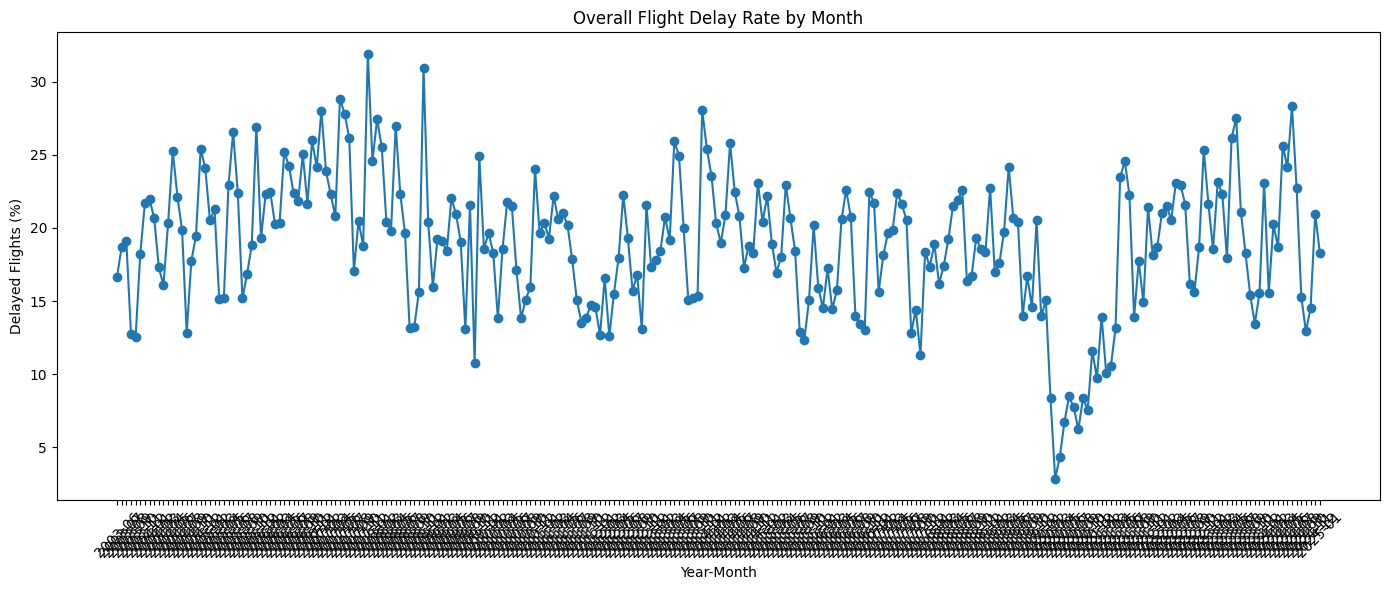

In [19]:
import matplotlib.pyplot as plt

monthly_delay_pd = monthly_delay_summary.toPandas()

plt.figure(figsize=(14, 6))

plt.plot(
    monthly_delay_pd["period"],
    monthly_delay_pd["overall_delay_rate"] * 100,
    marker="o"
)

plt.title("Overall Flight Delay Rate by Month")
plt.xlabel("Year-Month")
plt.ylabel("Delayed Flights (%)")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

**How to interpret this chart:** Each marker represents one year-month. Look for sustained upward or downward movement, as well as isolated spikes that may warrant deeper investigation. The chart measures the proportion of arriving flights delayed by 15 minutes or more, not simply the number of delayed flights.


## 7. Question 2 — Airlines with the Highest Delay Rates

**Business question:** Which airlines have the highest percentage of delayed flights?

Each carrier’s rate is calculated with total delayed flights divided by total arriving flights across all available airport-month records. This compares airlines by the proportion of flights delayed rather than by raw delay volume alone.


In [20]:
carrier_delay_summary = (
    airline_metrics
    .groupBy("carrier_name")
    .agg(
        F.sum("arr_del15").alias("total_delayed_flights"),
        F.sum("arr_flights").alias("total_arriving_flights")
    )
    .withColumn(
        "carrier_delay_rate",
        F.col("total_delayed_flights") / F.col("total_arriving_flights")
    )
    .orderBy(
        F.col("carrier_delay_rate").desc()
    )
)

carrier_delay_summary.show(20, truncate=False)

+-----------------------------------------+---------------------+----------------------+-------------------+
|carrier_name                             |total_delayed_flights|total_arriving_flights|carrier_delay_rate |
+-----------------------------------------+---------------------+----------------------+-------------------+
|Peninsula Airways Inc.                   |1015                 |3227                  |0.31453362255965295|
|Frontier Airlines                        |272946               |1041066               |0.2621793430964031 |
|Trans States Airlines                    |43815                |178098                |0.24601623825085064|
|Atlantic Southeast Airlines              |618201               |2526762               |0.24466134918919946|
|JetBlue Airways                          |1151344              |4720734               |0.24389088645960563|
|Commutair Aka Champlain Enterprises, Inc.|68214                |280544                |0.24314902475191058|
|Allegiant Air     

### Visualisation: Top 20 Airline Delay Rates

A horizontal bar chart is used because airline names can be long. Limiting the chart to the top 20 makes the comparison readable while the Spark summary retains all carriers for inspection.


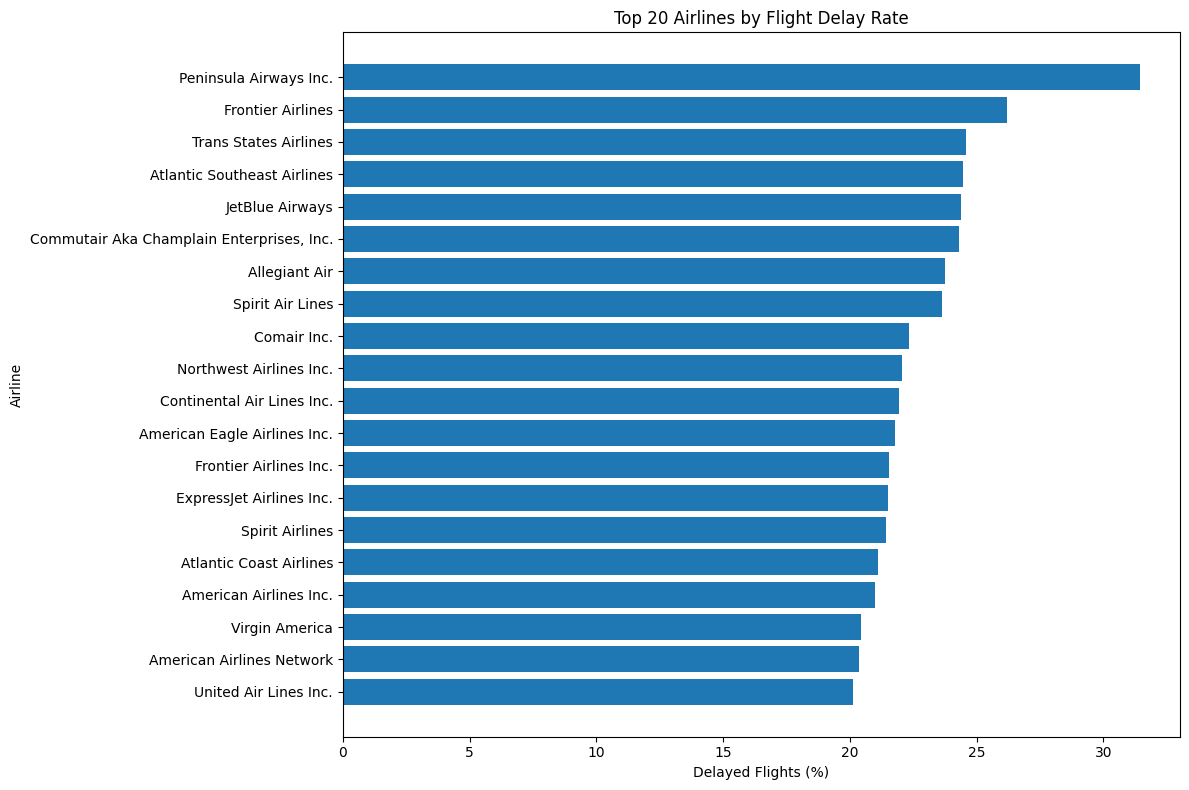

In [21]:
top_carriers_pd = (
    carrier_delay_summary
    .limit(20)
    .toPandas()
)

plt.figure(figsize=(12, 8))

plt.barh(
    top_carriers_pd["carrier_name"],
    top_carriers_pd["carrier_delay_rate"] * 100
)

plt.title("Top 20 Airlines by Flight Delay Rate")
plt.xlabel("Delayed Flights (%)")
plt.ylabel("Airline")

plt.gca().invert_yaxis()
plt.tight_layout()

plt.show()

**How to interpret this chart:** Longer bars indicate a higher share of delayed arriving flights. Compare these findings with total flight volume before drawing conclusions about operational scale or service quality.


## 8. Question 3 — Carrier-Caused Delays by Airline

**Business question:** Which airlines experience the most delays attributed to carrier-related causes?

This section uses `carrier_ct`, which represents the delay-attributed count for carrier causes. Unlike Question 2, this is a volume question, so we sum the delay counts rather than calculating a rate. Larger operators may have higher totals partly because they operate more flights; that context should be considered when interpreting the chart.


In [22]:
carrier_caused_summary = (
    airline_metrics
    .groupBy("carrier_name")
    .agg(
        F.sum("carrier_ct").alias("total_carrier_caused_delays")
    )
    .orderBy(
        F.col("total_carrier_caused_delays").desc()
    )
)

carrier_caused_summary.show(20, truncate=False)

+----------------------------+---------------------------+
|carrier_name                |total_carrier_caused_delays|
+----------------------------+---------------------------+
|SkyWest Airlines Inc.       |873465.6399999987          |
|Southwest Airlines Co.      |862382.4499999996          |
|Southwest Airlines          |572138.8499999996          |
|American Airlines Inc.      |557837.3600000013          |
|Delta Air Lines Inc.        |486205.5400000016          |
|American Airlines Network   |394088.7200000002          |
|United Air Lines Inc.       |383910.7000000003          |
|ExpressJet Airlines Inc.    |370796.6800000004          |
|JetBlue Airways             |362771.3800000007          |
|Delta Air Lines Network     |338247.55999999994         |
|American Eagle Airlines Inc.|280421.53999999946         |
|US Airways Inc.             |272573.00999999966         |
|United Air Lines Network    |228146.0799999994          |
|Atlantic Southeast Airlines |218409.84999999977        

### Visualisation: Top 20 Airlines by Carrier-Caused Delay Count

The horizontal bar chart ranks airlines by their accumulated carrier-caused delay counts. The result is useful for operational prioritisation, while Question 2 provides the complementary percentage-based view.


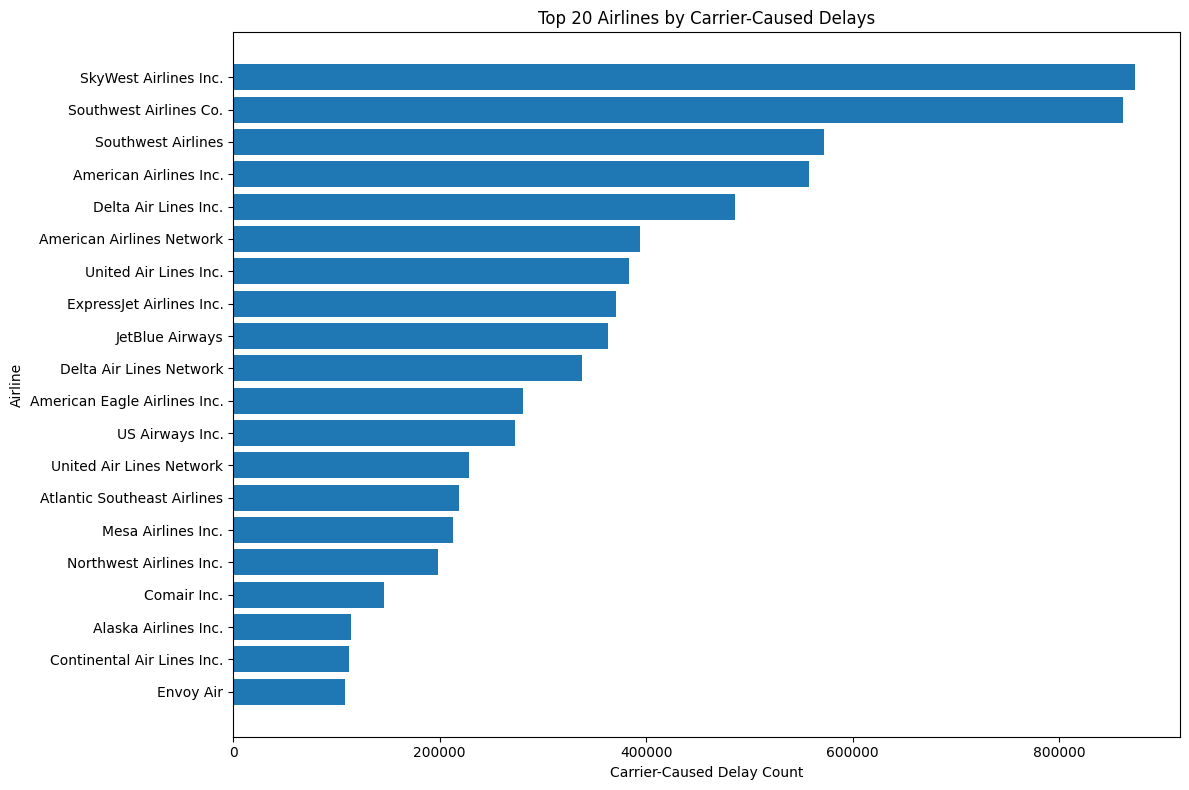

In [23]:
carrier_caused_pd = (
    carrier_caused_summary
    .limit(20)
    .toPandas()
)

plt.figure(figsize=(12, 8))

plt.barh(
    carrier_caused_pd["carrier_name"],
    carrier_caused_pd["total_carrier_caused_delays"]
)

plt.title("Top 20 Airlines by Carrier-Caused Delays")
plt.xlabel("Carrier-Caused Delay Count")
plt.ylabel("Airline")

plt.gca().invert_yaxis()
plt.tight_layout()

plt.show()

**How to interpret this chart:** Longer bars indicate more delays attributed to carrier-related causes. This result should be considered alongside the percentage-based ranking in Question 2.


## 9. Question 4 — Airports with the Highest Delay Rates

**Business question:** Which airports have the highest percentage of delayed arriving flights?

The calculation uses total delayed flights divided by total arriving flights for each airport. A minimum volume threshold of 1,000 arriving flights is applied before ranking: this prevents a very small airport with one delayed flight out of one flight from appearing misleadingly as the worst-performing airport.


In [24]:
airport_delay_summary = (
    airline_metrics
    .groupBy("airport", "airport_name")
    .agg(
        F.sum("arr_del15").alias("total_delayed_flights"),
        F.sum("arr_flights").alias("total_arriving_flights")
    )
    .withColumn(
        "airport_delay_rate",
        F.col("total_delayed_flights") / F.col("total_arriving_flights")
    )
    .filter(
        F.col("total_arriving_flights") >= 1000
    )
    .orderBy(
        F.col("airport_delay_rate").desc()
    )
)

airport_delay_summary.show(20, truncate=False)

+-------+--------------------------------------------------------+---------------------+----------------------+-------------------+
|airport|airport_name                                            |total_delayed_flights|total_arriving_flights|airport_delay_rate |
+-------+--------------------------------------------------------+---------------------+----------------------+-------------------+
|DUT    |Unalaska, AK: Unalaska Airport                          |770                  |2074                  |0.3712632594021215 |
|ILG    |Wilmington, DE: New Castle                              |688                  |2121                  |0.3243752946723244 |
|MCN    |Macon, GA: Middle Georgia Regional                      |2050                 |6483                  |0.31621163041801637|
|BQN    |Aguadilla, PR: Rafael Hernandez                         |9692                 |33747                 |0.2871958988947166 |
|SCK    |Stockton, CA: Stockton Metro                            |619       

### Visualisation: Top 20 Airports by Delay Rate

Airport codes are used on the chart to keep labels legible. The full airport name remains in the Spark output table for interpretation and reporting.


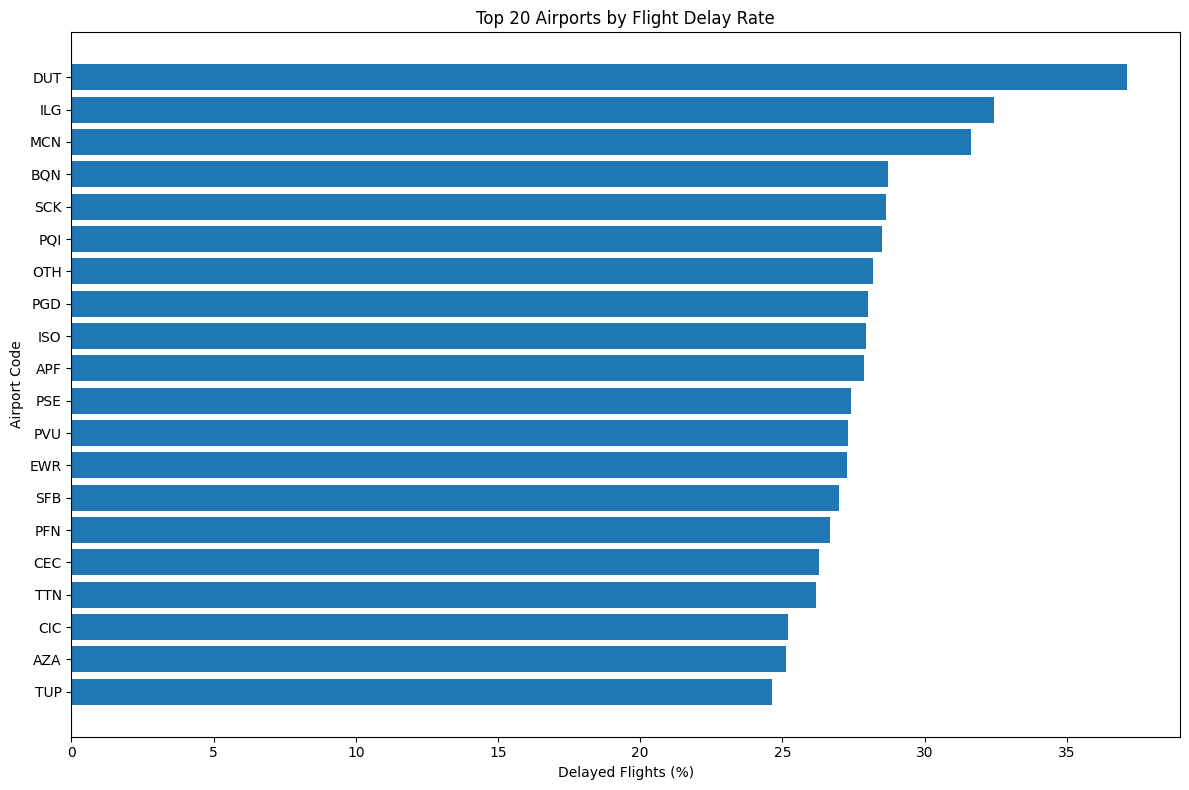

In [25]:
top_airports_pd = (
    airport_delay_summary
    .limit(20)
    .toPandas()
)

plt.figure(figsize=(12, 8))

plt.barh(
    top_airports_pd["airport"],
    top_airports_pd["airport_delay_rate"] * 100
)

plt.title("Top 20 Airports by Flight Delay Rate")
plt.xlabel("Delayed Flights (%)")
plt.ylabel("Airport Code")

plt.gca().invert_yaxis()
plt.tight_layout()

plt.show()

**How to interpret this chart:** Longer bars indicate a higher delayed-flight percentage among airports meeting the minimum traffic threshold. The threshold makes the ranking less sensitive to very small flight counts.


## 10. Question 5 — Dominant Delay Causes by Year

**Business question:** What share of recorded delay causes came from carrier, weather, NAS, security, and late-aircraft factors each year?

The source dataset stores each cause in a separate column, a structure known as **wide format**. To support a stacked chart and reusable cause analysis, the next cell reshapes those columns into a long-format table with four fields: `year`, `month`, `cause`, and `delay_count`. Keeping both year and month allows the same DataFrame to support Questions 5 and 6.


In [34]:
cause_long = (
    airline_metrics
    .select(
        "year",
        "month",
        F.lit("Carrier").alias("cause"),
        F.col("carrier_ct").alias("delay_count")
    )
    .unionByName(
        airline_metrics.select(
            "year",
            "month",
            F.lit("Weather").alias("cause"),
            F.col("weather_ct").alias("delay_count")
        )
    )
    .unionByName(
        airline_metrics.select(
            "year",
            "month",
            F.lit("NAS").alias("cause"),
            F.col("nas_ct").alias("delay_count")
        )
    )
    .unionByName(
        airline_metrics.select(
            "year",
            "month",
            F.lit("Security").alias("cause"),
            F.col("security_ct").alias("delay_count")
        )
    )
    .unionByName(
        airline_metrics.select(
            "year",
            "month",
            F.lit("Late Aircraft").alias("cause"),
            F.col("late_aircraft_ct").alias("delay_count")
        )
    )
)

### Aggregate Annual Cause Shares

For every year and cause, Spark sums the attributed delay count. It then calculates the total across all five causes for that year and derives a percentage share. Each yearly stacked bar should therefore sum to approximately 100%.


In [35]:
cause_by_year = (
    cause_long
    .groupBy("year", "cause")
    .agg(
        F.sum("delay_count").alias("total_delay_count")
    )
)

annual_cause_totals = (
    cause_by_year
    .groupBy("year")
    .agg(
        F.sum("total_delay_count").alias("all_cause_delay_count")
    )
)

cause_distribution = (
    cause_by_year
    .join(
        annual_cause_totals,
        on="year",
        how="inner"
    )
    .withColumn(
        "cause_percentage",
        (
            F.col("total_delay_count") /
            F.col("all_cause_delay_count")
        ) * 100
    )
    .orderBy("year", "cause")
)

cause_distribution.show(100, truncate=False)

+----+-------------+------------------+---------------------+-------------------+
|year|cause        |total_delay_count |all_cause_delay_count|cause_percentage   |
+----+-------------+------------------+---------------------+-------------------+
|2003|Carrier      |164663.44999999992|653971.1100000006    |25.179009818950533 |
|2003|Late Aircraft|178507.31000000026|653971.1100000006    |27.295901496321466 |
|2003|NAS          |281803.4000000005 |653971.1100000006    |43.091108413030696 |
|2003|Security     |2189.2999999999984|653971.1100000006    |0.3347701399225413 |
|2003|Weather      |26807.649999999947|653971.1100000006    |4.09921013177477   |
|2004|Carrier      |363577.4500000017 |1421392.9400000013   |25.578954261585213 |
|2004|Late Aircraft|420421.50000000006|1421392.9400000013   |29.578133404827494 |
|2004|NAS          |561139.1199999994 |1421392.9400000013   |39.478113631266446 |
|2004|Security     |4648.730000000007 |1421392.9400000013   |0.3270545300443101 |
|2004|Weather   

### Visualisation: Annual Delay Cause Distribution

The Spark result is converted to pandas only after it has been aggregated to a small year-by-cause table. Pandas `pivot()` converts the long-format data into the wide layout required by a stacked bar chart.


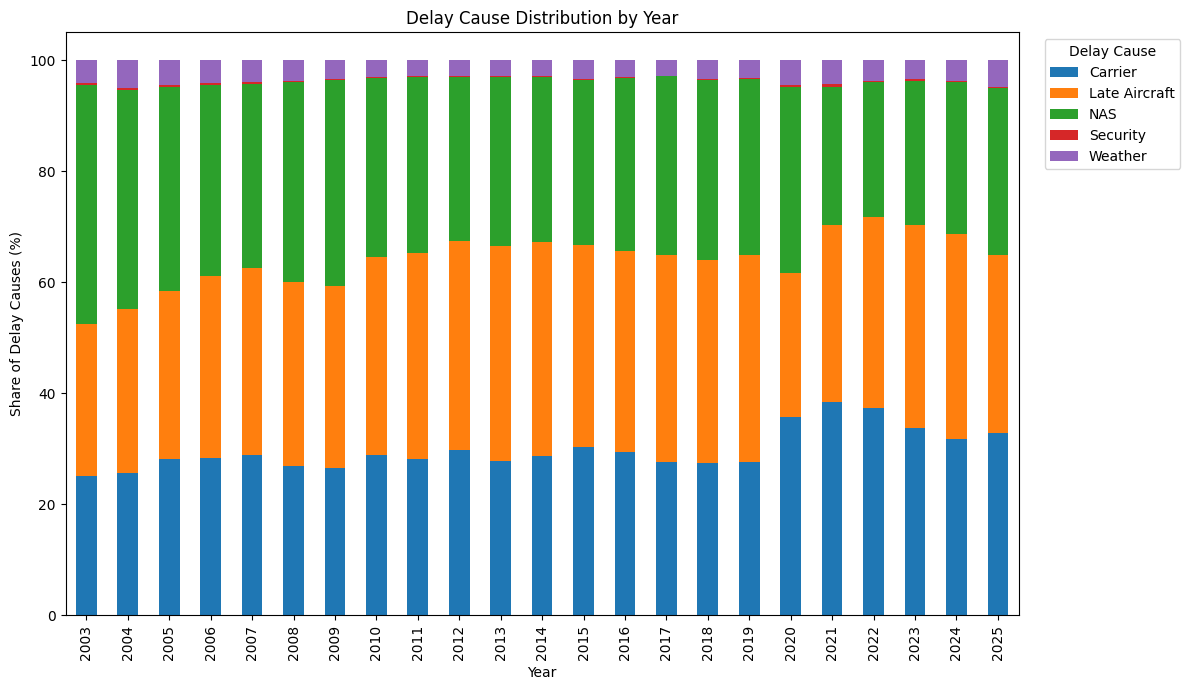

In [36]:
cause_distribution_pd = cause_distribution.toPandas()

cause_pivot = (
    cause_distribution_pd
    .pivot(
        index="year",
        columns="cause",
        values="cause_percentage"
    )
    .fillna(0)
    .sort_index()
)

cause_pivot.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 7)
)

plt.title("Delay Cause Distribution by Year")
plt.xlabel("Year")
plt.ylabel("Share of Delay Causes (%)")

plt.legend(
    title="Delay Cause",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

**How to interpret this chart:** Each coloured segment represents one cause’s percentage share of all recorded delay causes in that year. Compare segment sizes across years to identify changes in the composition of operational delay drivers.


## 11. Question 6 — Seasonal Patterns in Delay Causes

**Business question:** How do carrier, weather, NAS, security, and late-aircraft delay causes vary across the calendar year?

The analysis groups the long-format cause data by `month` and `cause`, summing delay-attributed counts across all years. This produces a seasonal view rather than a year-specific trend.


In [37]:
cause_by_month = (
    cause_long
    .groupBy("month", "cause")
    .agg(
        F.sum("delay_count").alias("total_delay_count")
    )
    .orderBy("month", "cause")
)

cause_by_month.show(100, truncate=False)

+-----+-------------+------------------+
|month|cause        |total_delay_count |
+-----+-------------+------------------+
|1    |Carrier      |695229.3900000013 |
|1    |Late Aircraft|776527.4600000014 |
|1    |NAS          |775301.3099999991 |
|1    |Security     |5874.9            |
|1    |Weather      |101214.84000000013|
|2    |Carrier      |587378.56         |
|2    |Late Aircraft|686051.4100000008 |
|2    |NAS          |697369.4699999995 |
|2    |Security     |4636.6900000000005|
|2    |Weather      |80368.43999999994 |
|3    |Carrier      |668602.830000001  |
|3    |Late Aircraft|795935.029999996  |
|3    |NAS          |736361.5999999982 |
|3    |Security     |5840.680000000004 |
|3    |Weather      |65666.41999999998 |
|4    |Carrier      |592979.5999999979 |
|4    |Late Aircraft|704912.0799999987 |
|4    |NAS          |657975.9999999999 |
|4    |Security     |4879.580000000004 |
|4    |Weather      |60836.24000000002 |
|5    |Carrier      |629577.3299999969 |
|5    |Late Airc

### Visualisation: Monthly Pattern of Delay Causes

The pandas pivot creates one column per cause, allowing Matplotlib to draw one line per delay cause. The chart helps identify months where a specific operational cause rises or falls relative to the others. Interpret visible patterns from the data; do not assume a seasonal explanation without evidence.


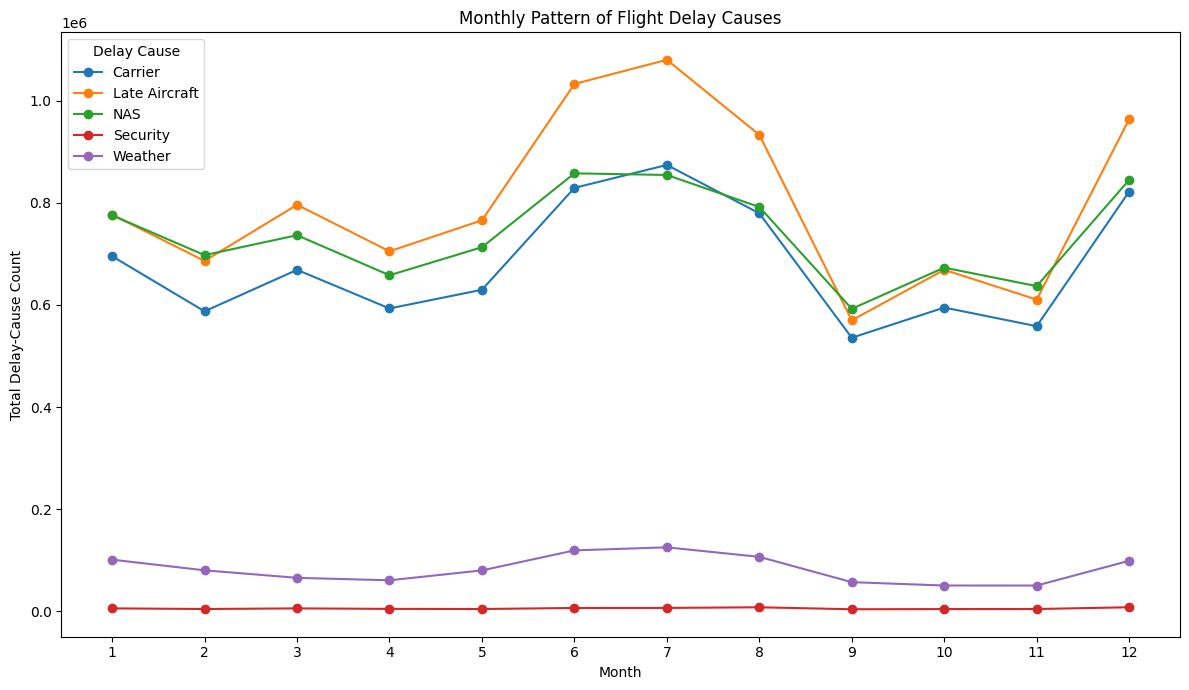

In [38]:
cause_by_month_pd = cause_by_month.toPandas()

monthly_cause_pivot = (
    cause_by_month_pd
    .pivot(
        index="month",
        columns="cause",
        values="total_delay_count"
    )
    .fillna(0)
    .sort_index()
)

plt.figure(figsize=(12, 7))

for cause in monthly_cause_pivot.columns:
    plt.plot(
        monthly_cause_pivot.index,
        monthly_cause_pivot[cause],
        marker="o",
        label=cause
    )

plt.title("Monthly Pattern of Flight Delay Causes")
plt.xlabel("Month")
plt.ylabel("Total Delay-Cause Count")

plt.xticks(range(1, 13))
plt.legend(title="Delay Cause")

plt.tight_layout()
plt.show()


**How to interpret this chart:** Each line represents a delay cause. Peaks indicate months with comparatively higher attributed delay counts for that cause. Since the values are counts, flight volume should be considered when interpreting seasonal changes.


## 12. Question 7 — Months with the Highest and Lowest Delay Rates

**Business question:** Which calendar months have the highest and lowest overall percentage of delayed flights?

Unlike Question 1, this step combines the same month across all years. All January records are aggregated together, all February records together, and so on. This isolates recurring seasonal behaviour in the delay rate.


In [39]:
monthly_seasonality_summary = (
    airline_metrics
    .groupBy("month")
    .agg(
        F.sum("arr_del15").alias("total_delayed_flights"),
        F.sum("arr_flights").alias("total_arriving_flights")
    )
    .withColumn(
        "monthly_delay_rate",
        F.col("total_delayed_flights") / F.col("total_arriving_flights")
    )
    .orderBy("month")
)

monthly_seasonality_summary.show(12, truncate=False)

+-----+---------------------+----------------------+-------------------+
|month|total_delayed_flights|total_arriving_flights|monthly_delay_rate |
+-----+---------------------+----------------------+-------------------+
|1    |2354148              |11988521              |0.1963668412475567 |
|2    |2055802              |10553304              |0.19480174171046338|
|3    |2272405              |12121573              |0.18746783111399815|
|4    |2021582              |11409296              |0.17718726904797633|
|5    |2192840              |11636972              |0.18843733576053978|
|6    |2845053              |12331062              |0.2307224633206775 |
|7    |2940136              |12907171              |0.2277908923651821 |
|8    |2618484              |12850510              |0.20376498675928037|
|9    |1759080              |11804903              |0.14901266024803422|
|10   |1991538              |12335061              |0.16145343748198732|
|11   |1860435              |11770852              

### Visualisation: Monthly Delay-Rate Seasonality

The line chart uses months 1–12 on the x-axis and the weighted monthly delay rate on the y-axis. The highest and lowest points identify the calendar months with the greatest and least overall delay pressure in the available data.


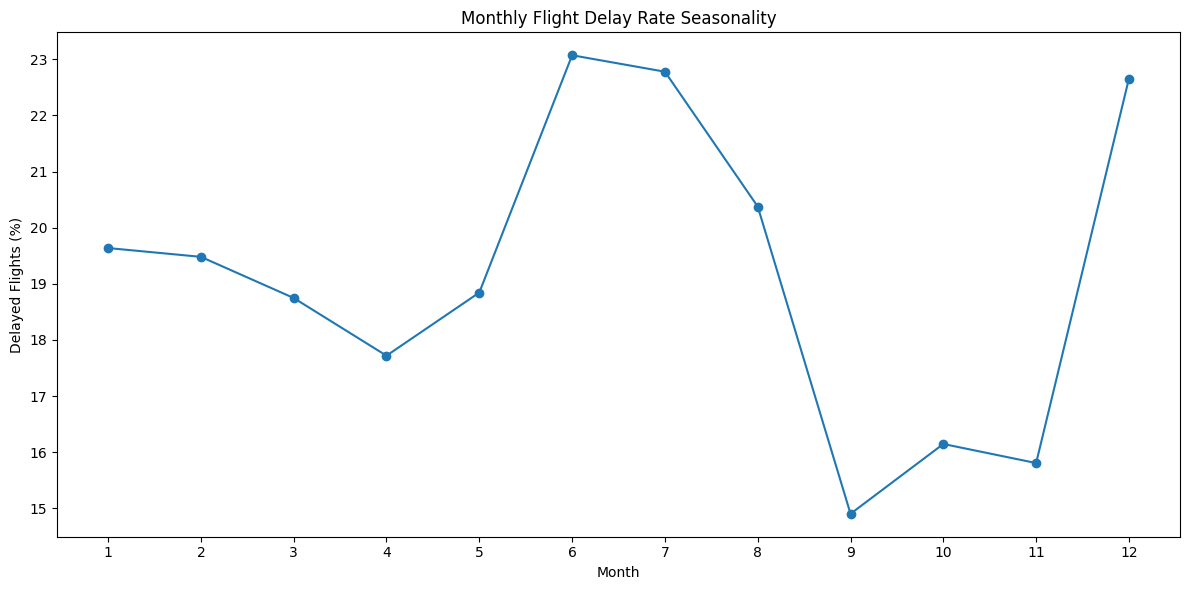

In [40]:
monthly_seasonality_pd = monthly_seasonality_summary.toPandas()

plt.figure(figsize=(12, 6))

plt.plot(
    monthly_seasonality_pd["month"],
    monthly_seasonality_pd["monthly_delay_rate"] * 100,
    marker="o"
)

plt.title("Monthly Flight Delay Rate Seasonality")
plt.xlabel("Month")
plt.ylabel("Delayed Flights (%)")

plt.xticks(range(1, 13))
plt.tight_layout()

plt.show()

---

## 13. Project Conclusion and Portfolio Notes

This notebook demonstrates an end-to-end PySpark workflow: source-data inspection, evidence-based null handling, feature engineering, weighted aggregation, and scalable chart preparation.

For a GitHub repository, pair this notebook with a concise README that explains the business objective, dataset source and licence, key engineering decisions, the seven analytical questions, and three to five findings based on the final charts. Keep any stated findings traceable to the notebook outputs.

**Core skills demonstrated:** PySpark DataFrames, Spark SQL functions, missing-value validation, feature engineering, `groupBy` aggregations, `unionByName`, pandas conversion for small results, and Matplotlib visualisation.
